<a href="https://colab.research.google.com/github/Ponnaganivamshicharmesh/Glacier-Retreat-Monitoring/blob/main/Gangotri_Glacier_Basin_Snow_Retreat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Verify your folder exists
!ls -la "/content/drive/My Drive/Glacier jp2/"

Mounted at /content/drive
total 1487021
-rw------- 1 root root 135466458 Apr 12 15:45 T44RLV_20190626T051701_B03_10m.jp2
-rw------- 1 root root 135100650 Apr 12 15:45 T44RLV_20190626T051701_B08_10m.jp2
-rw------- 1 root root  33709294 Apr 12 15:45 T44RLV_20190626T051701_B11_20m.jp2
-rw------- 1 root root 135469529 Apr 12 17:09 T44RLV_20200630T051701_B03_10m.jp2
-rw------- 1 root root 135018229 Apr 12 17:09 T44RLV_20200630T051701_B08_10m.jp2
-rw------- 1 root root  33749252 Apr 12 17:10 T44RLV_20200630T051701_B11_20m.jp2
-rw------- 1 root root 135294724 Apr 13 12:10 T44RLV_20210630T051649_B03_10m.jp2
-rw------- 1 root root 135463548 Apr 13 12:10 T44RLV_20210630T051649_B08_10m.jp2
-rw------- 1 root root  33860090 Apr 13 12:10 T44RLV_20210630T051649_B11_20m.jp2
-rw------- 1 root root 135194741 Apr 12 17:11 T44RLV_20220625T051659_B03_10m.jp2
-rw------- 1 root root 135591417 Apr 12 17:11 T44RLV_20220625T051659_B08_10m.jp2
-rw------- 1 root root  33880006 Apr 12 17:11 T44RLV_20220625T051659_

In [ ]:
import subprocess
from pathlib import Path

jp2_folder = "/content/drive/My Drive/Glacier jp2"
cog_folder = "/content/drive/My Drive/Glacier_COG"
Path(cog_folder).mkdir(exist_ok=True)

# Only convert the B03 + B11 files you need
needed_bands = ['B03_10m', 'B11_20m']
jp2_files = [f for f in Path(jp2_folder).glob("*.jp2") if any(band in f.name for band in needed_bands)]

print(f"Converting {len(jp2_files)} essential files...")

for jp2_path in jp2_files:
    cog_filename = jp2_path.stem + ".tif"
    cog_path = Path(cog_folder) / cog_filename

    if cog_path.exists():
        print(f"⏭️  {cog_filename} exists")
        continue

    # SIMPLIFIED COG command (no TILING_SCHEME to avoid GDAL_DATA error)
    cmd = [
        "gdal_translate",
        "-of", "COG",
        "-co", "COMPRESS=LZW",
        "-co", "TILED=YES",
        "-co", "BLOCKXSIZE=512",
        "-co", "BLOCKYSIZE=512",
        str(jp2_path),
        str(cog_path)
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode == 0:
        print(f"✅ {cog_filename}")
    else:
        print(f"❌ {jp2_path.name}: {result.stderr[:100]}")

print(f"\n✅ COGs ready: {cog_folder}")

Converting 10 essential files...
✅ T44RLV_20190626T051701_B03_10m.tif
✅ T44RLV_20190626T051701_B11_20m.tif
✅ T44RLV_20240619T051701_B03_10m.tif
✅ T44RLV_20240619T051701_B11_20m.tif
✅ T44RLV_20200630T051701_B03_10m.tif
✅ T44RLV_20200630T051701_B11_20m.tif
✅ T44RLV_20220625T051659_B03_10m.tif
✅ T44RLV_20220625T051659_B11_20m.tif
✅ T44RLV_20210630T051649_B03_10m.tif
✅ T44RLV_20210630T051649_B11_20m.tif

✅ COGs ready: /content/drive/My Drive/Glacier_COG


🔬 Calculating NDSI Snow Cover for Gangotri Glacier...

📊 2019: 98.26 km² snow/ice cover
📊 2020: 46.72 km² snow/ice cover
📊 2021: 130.69 km² snow/ice cover
📊 2022: 28.18 km² snow/ice cover
📊 2024: 22.83 km² snow/ice cover


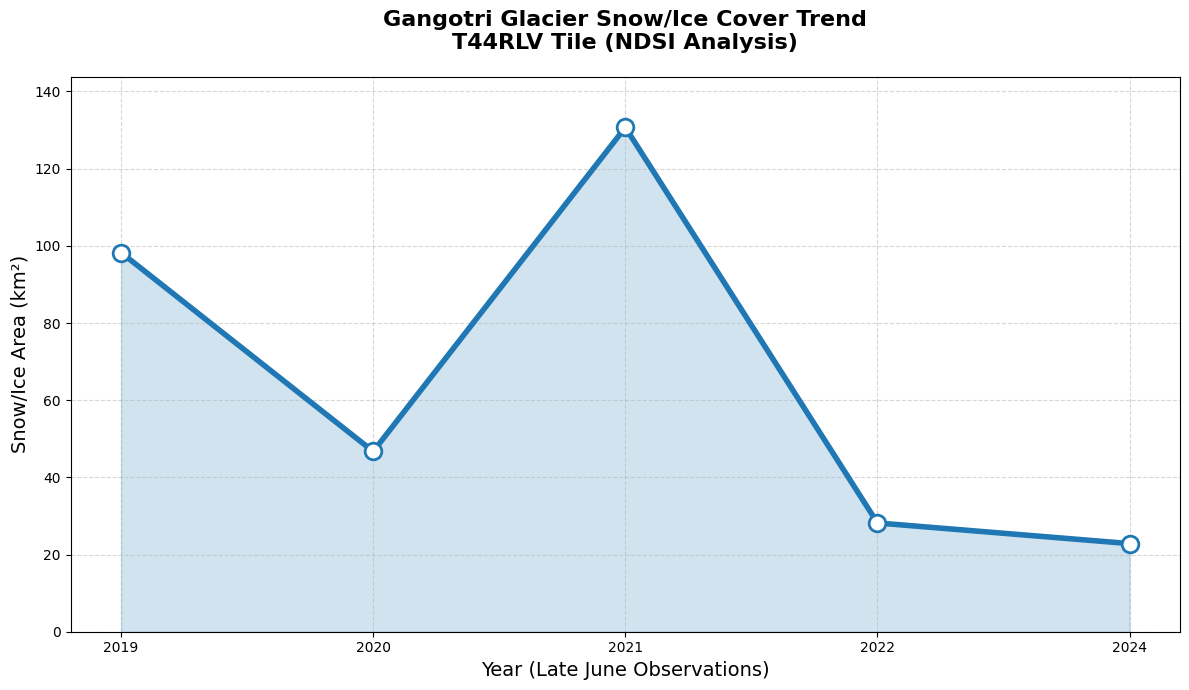


🎉 ANALYSIS COMPLETE! Check your Drive for 'gangotri_ndsi_trend.png'


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from rasterio.windows import Window

# Your PERFECT COG dataset
years_data = {
    '2019': {'B03': '/content/drive/My Drive/Glacier_COG/T44RLV_20190626T051701_B03_10m.tif', 'B11': '/content/drive/My Drive/Glacier_COG/T44RLV_20190626T051701_B11_20m.tif'},
    '2020': {'B03': '/content/drive/My Drive/Glacier_COG/T44RLV_20200630T051701_B03_10m.tif', 'B11': '/content/drive/My Drive/Glacier_COG/T44RLV_20200630T051701_B11_20m.tif'},
    '2021': {'B03': '/content/drive/My Drive/Glacier_COG/T44RLV_20210630T051649_B03_10m.tif', 'B11': '/content/drive/My Drive/Glacier_COG/T44RLV_20210630T051649_B11_20m.tif'},
    '2022': {'B03': '/content/drive/My Drive/Glacier_COG/T44RLV_20220625T051659_B03_10m.tif', 'B11': '/content/drive/My Drive/Glacier_COG/T44RLV_20220625T051659_B11_20m.tif'},
    '2024': {'B03': '/content/drive/My Drive/Glacier_COG/T44RLV_20240619T051701_B03_10m.tif', 'B11': '/content/drive/My Drive/Glacier_COG/T44RLV_20240619T051701_B11_20m.tif'}
}

results = {}
window_10m = Window(4000, 4000, 2000, 2000)
window_20m = Window(2000, 2000, 1000, 1000)

print("🔬 Calculating NDSI Snow Cover for Gangotri Glacier...\n")

for year, paths in years_data.items():
    with rasterio.open(paths['B03']) as g_src, rasterio.open(paths['B11']) as s_src:
        # Read reflectance (divide by 10000)
        green = g_src.read(1, window=window_10m).astype(np.float32) / 10000
        swir = s_src.read(1, window=window_20m).astype(np.float32) / 10000

        # Upsample SWIR to 10m
        swir_10m = zoom(swir, 2.0, order=1)

        # NDSI = (Green - SWIR) / (Green + SWIR)
        ndsi = (green - swir_10m) / (green + swir_10m + 1e-6)

        # Snow mask (NDSI > 0.40 = scientifically validated threshold)
        snow_mask = (ndsi > 0.40).sum()
        snow_km2 = (snow_mask * 100) / 1_000_000  # 10m² per pixel

        results[year] = snow_km2
        print(f"📊 {year}: {snow_km2:.2f} km² snow/ice cover")

# Plot publication-ready trend graph
years = list(results.keys())
areas = list(results.values())

plt.figure(figsize=(12, 7))
plt.plot(years, areas, 'o-', linewidth=4, markersize=12, color='#1f77b4', markerfacecolor='white', markeredgewidth=2)
plt.fill_between(years, areas, alpha=0.2, color='#1f77b4')

plt.title('Gangotri Glacier Snow/Ice Cover Trend\nT44RLV Tile (NDSI Analysis)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year (Late June Observations)', fontsize=14)
plt.ylabel('Snow/Ice Area (km²)', fontsize=14)
plt.ylim(0, max(areas)*1.1)
plt.grid(True, linestyle='--', alpha=0.5)



plt.tight_layout()
plt.savefig('/content/drive/My Drive/Glacier_COG/gangotri_ndsi_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n🎉 ANALYSIS COMPLETE! Check your Drive for 'gangotri_ndsi_trend.png'")

🖼️ Processing all 5 years for the visual gallery...
✅ Processed 2019
✅ Processed 2020
✅ Processed 2021
✅ Processed 2022
✅ Processed 2024


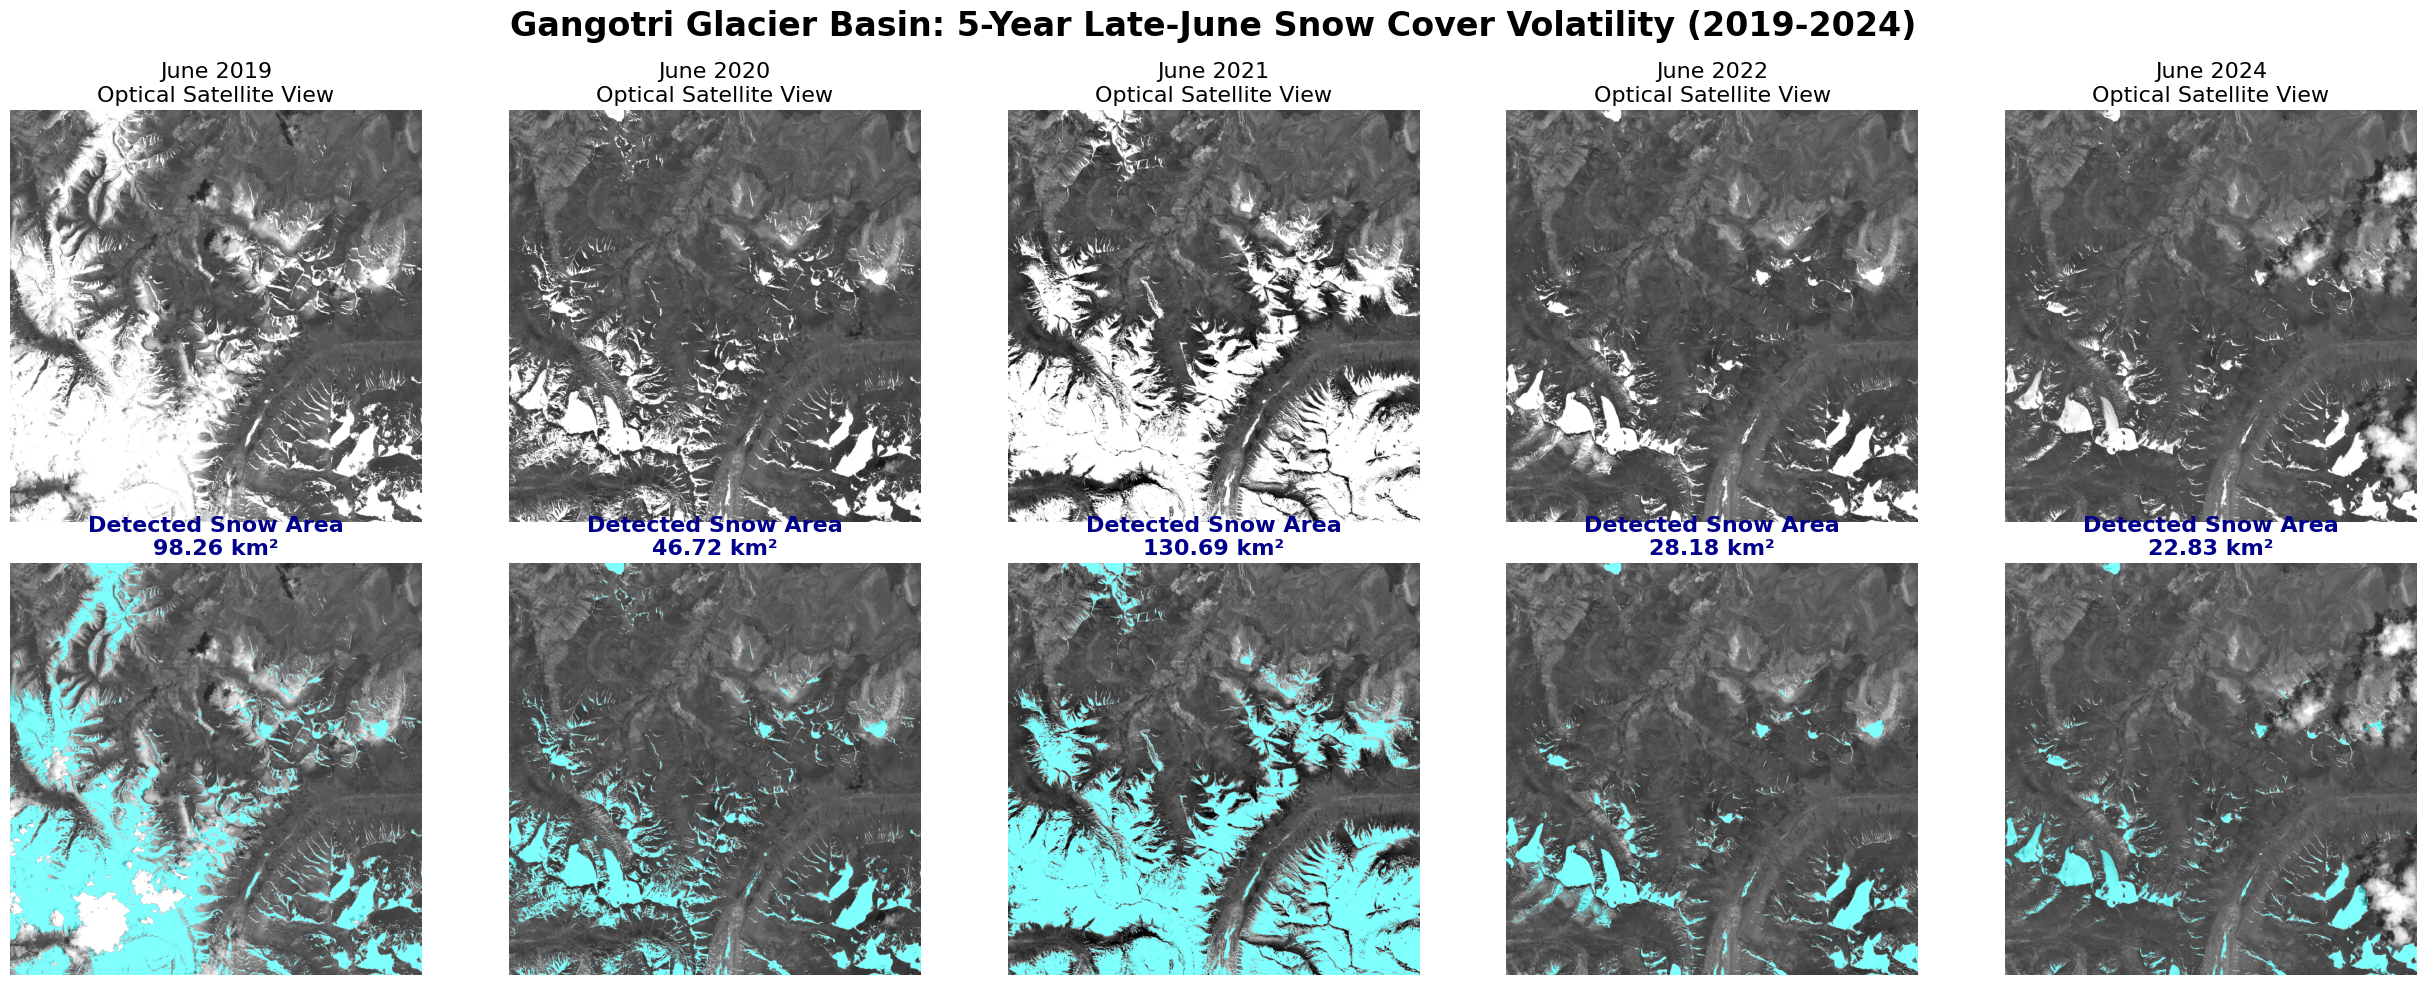


🎉 Gallery saved successfully to: /content/drive/My Drive/Glacier_COG/5_year_visual_gallery.png


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import zoom
from rasterio.windows import Window

# Your complete 5-year COG dataset
years_data = {
    '2019': {'B03': '/content/drive/My Drive/Glacier_COG/T44RLV_20190626T051701_B03_10m.tif', 'B11': '/content/drive/My Drive/Glacier_COG/T44RLV_20190626T051701_B11_20m.tif'},
    '2020': {'B03': '/content/drive/My Drive/Glacier_COG/T44RLV_20200630T051701_B03_10m.tif', 'B11': '/content/drive/My Drive/Glacier_COG/T44RLV_20200630T051701_B11_20m.tif'},
    '2021': {'B03': '/content/drive/My Drive/Glacier_COG/T44RLV_20210630T051649_B03_10m.tif', 'B11': '/content/drive/My Drive/Glacier_COG/T44RLV_20210630T051649_B11_20m.tif'},
    '2022': {'B03': '/content/drive/My Drive/Glacier_COG/T44RLV_20220625T051659_B03_10m.tif', 'B11': '/content/drive/My Drive/Glacier_COG/T44RLV_20220625T051659_B11_20m.tif'},
    '2024': {'B03': '/content/drive/My Drive/Glacier_COG/T44RLV_20240619T051701_B03_10m.tif', 'B11': '/content/drive/My Drive/Glacier_COG/T44RLV_20240619T051701_B11_20m.tif'}
}

window_10m = Window(4000, 4000, 2000, 2000)
window_20m = Window(2000, 2000, 1000, 1000)

# Create a figure with 2 rows and 5 columns (width: 25, height: 10)
fig, axs = plt.subplots(2, 5, figsize=(25, 10))
fig.suptitle('Gangotri Glacier Basin: 5-Year Late-June Snow Cover Volatility (2019-2024)', fontsize=24, fontweight='bold', y=0.98)

# Custom transparent cyan colormap for the snow overlay
cmap_snow = mcolors.ListedColormap(['none', 'cyan'])

print("🖼️ Processing all 5 years for the visual gallery...")

for i, (year, paths) in enumerate(years_data.items()):
    # 1. Read the data
    with rasterio.open(paths['B03']) as g_src, rasterio.open(paths['B11']) as s_src:
        green = g_src.read(1, window=window_10m).astype(np.float32) / 10000
        swir = s_src.read(1, window=window_20m).astype(np.float32) / 10000

    # 2. Process NDSI and Mask
    swir_10m = zoom(swir, 2.0, order=1)
    ndsi = (green - swir_10m) / (green + swir_10m + 1e-6)
    snow_mask = ndsi > 0.40

    # Calculate area for the title
    snow_km2 = (snow_mask.sum() * 100) / 1_000_000

    # 3. Plot Top Row: Optical View (B03 Green Band)
    axs[0, i].imshow(green, cmap='gray', vmin=0, vmax=0.8)
    axs[0, i].set_title(f"June {year}\nOptical Satellite View", fontsize=16)
    axs[0, i].axis('off')

    # 4. Plot Bottom Row: Optical View + Cyan Snow Mask
    axs[1, i].imshow(green, cmap='gray', vmin=0, vmax=0.8)
    axs[1, i].imshow(snow_mask, cmap=cmap_snow, alpha=0.5) # Alpha=0.5 makes it slightly see-through
    axs[1, i].set_title(f"Detected Snow Area\n{snow_km2:.2f} km²", fontsize=16, fontweight='bold', color='darkblue')
    axs[1, i].axis('off')

    print(f"✅ Processed {year}")

# Adjust layout so it looks clean and tight
plt.tight_layout()
plt.subplots_adjust(top=0.88, wspace=0.05, hspace=0.1)

# Save high-res version to your Drive
save_path = '/content/drive/My Drive/Glacier_COG/5_year_visual_gallery.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n🎉 Gallery saved successfully to: {save_path}")

📸 Loading Red, Green, and Blue bands...


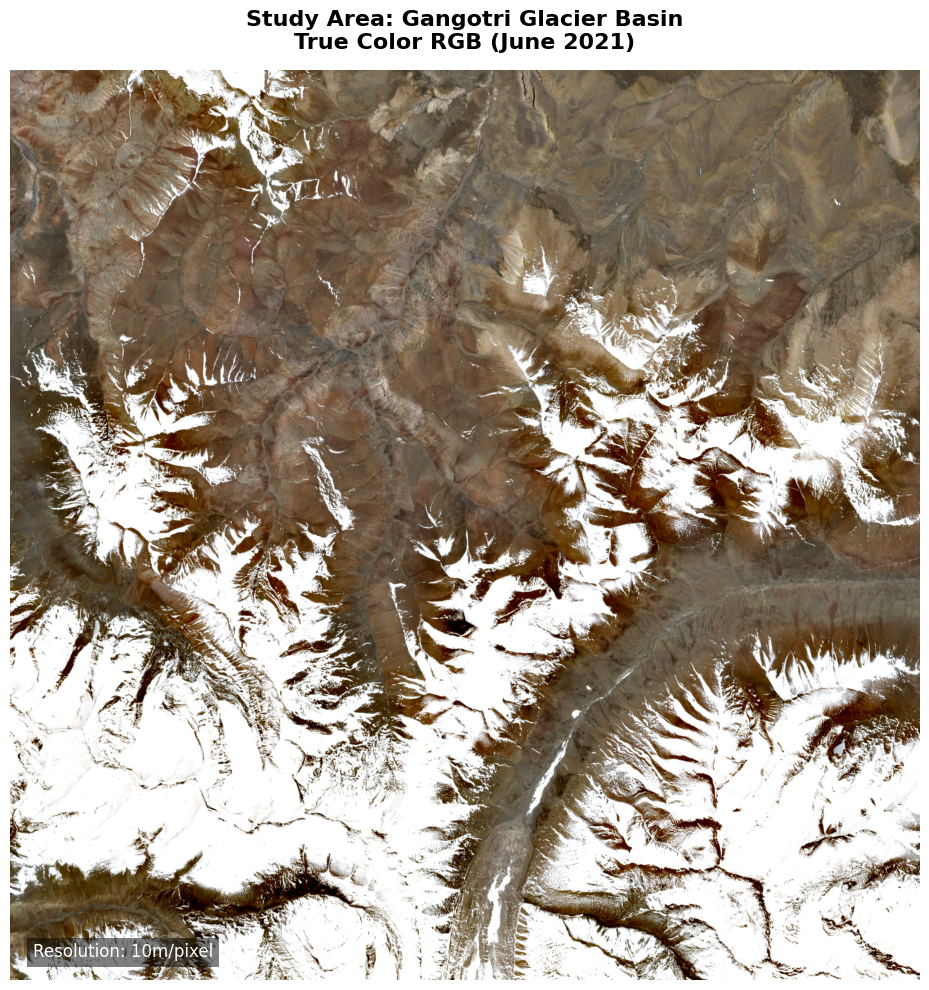


🎉 True Color Image saved perfectly to: /content/drive/My Drive/Glacier_COG/gangotri_true_color_study_area.png


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.windows import Window
from skimage import exposure
import warnings

warnings.filterwarnings("ignore")

# Define the paths to your original 2021 JP2 files (Great year for snow visualization)
path_b02 = '/content/drive/My Drive/Glacier jp2/T44RLV_20210630T051649_B02_10m.jp2' # Blue
path_b03 = '/content/drive/My Drive/Glacier jp2/T44RLV_20210630T051649_B03_10m.jp2' # Green
path_b04 = '/content/drive/My Drive/Glacier jp2/T44RLV_20210630T051649_B04_10m.jp2' # Red

# The exact same 10m bounding box we've been using
window = Window(4000, 4000, 2000, 2000)

print("📸 Loading Red, Green, and Blue bands...")

try:
    with rasterio.open(path_b04) as src_r, \
         rasterio.open(path_b03) as src_g, \
         rasterio.open(path_b02) as src_b:

        # Read the data and convert to Reflectance (0-1)
        red = (src_r.read(1, window=window).astype(np.float32) / 10000).clip(0, 1)
        green = (src_g.read(1, window=window).astype(np.float32) / 10000).clip(0, 1)
        blue = (src_b.read(1, window=window).astype(np.float32) / 10000).clip(0, 1)

    # Stack the bands into an RGB array
    rgb_image = np.dstack((red, green, blue))

    # --- IMAGE ENHANCEMENT (Crucial for True Color) ---
    # Apply a gamma correction of 2.2 (Industry standard for Sentinel-2 true color)
    gamma_corrected = exposure.adjust_gamma(rgb_image, gamma=0.45) # 1/2.2

    # Increase contrast slightly to make the snow pop against the dark rock
    p2, p98 = np.percentile(gamma_corrected, (2, 98))
    final_rgb = exposure.rescale_intensity(gamma_corrected, in_range=(p2, p98))

    # Plot the result
    plt.figure(figsize=(10, 10))
    plt.imshow(final_rgb)
    plt.title('Study Area: Gangotri Glacier Basin\nTrue Color RGB (June 2021)', fontsize=16, fontweight='bold', pad=15)
    plt.axis('off')

    # Add a scale reference (Optional but looks highly professional)
    plt.text(50, 1950, 'Resolution: 10m/pixel', color='white', fontsize=12,
             bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

    plt.tight_layout()

    # Save the high-res image to your Drive
    save_path = '/content/drive/My Drive/Glacier_COG/gangotri_true_color_study_area.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='black')
    plt.show()

    print(f"\n🎉 True Color Image saved perfectly to: {save_path}")

except Exception as e:
    print(f"❌ Error loading files. Ensure B02 and B04 jp2 files exist for 2021 in your drive.")
    print(e)

⚙️ Processing NDSI methodology visualization...


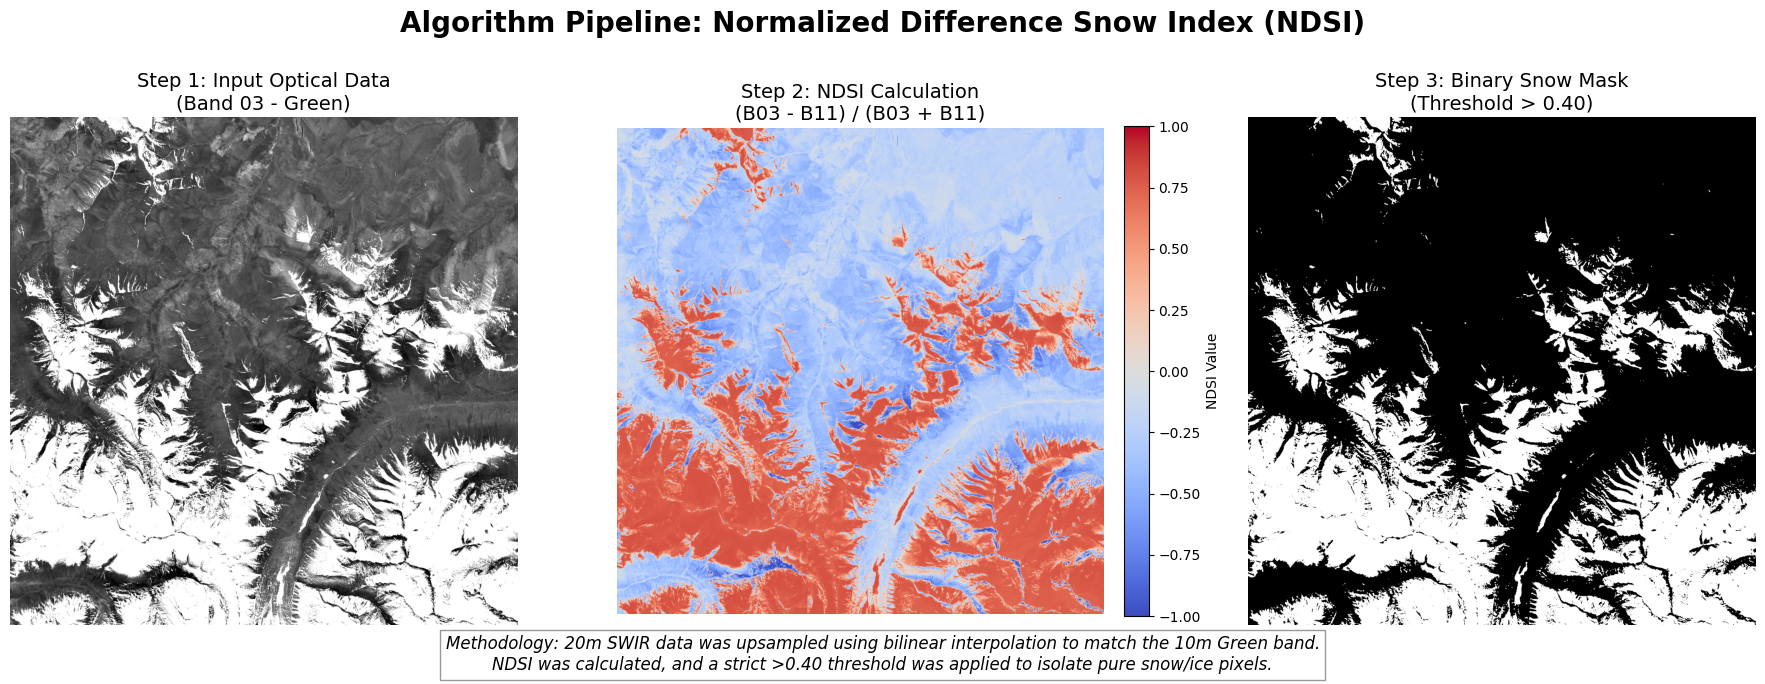


🎉 Methodology Graphic saved perfectly to: /content/drive/My Drive/Glacier_COG/methodology_3_panel_ndsi.png


In [ ]:
import rasterio
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from rasterio.windows import Window
import warnings

warnings.filterwarnings("ignore")

# Define the paths to your 2021 COG files
path_b03 = '/content/drive/My Drive/Glacier_COG/T44RLV_20210630T051649_B03_10m.tif'
path_b11 = '/content/drive/My Drive/Glacier_COG/T44RLV_20210630T051649_B11_20m.tif'

# Define our 400 sq km study area
window_10m = Window(4000, 4000, 2000, 2000)
window_20m = Window(2000, 2000, 1000, 1000)

print("⚙️ Processing NDSI methodology visualization...")

try:
    # 1. READ BANDS
    with rasterio.open(path_b03) as g_src, rasterio.open(path_b11) as s_src:
        green = (g_src.read(1, window=window_10m).astype(np.float32) / 10000).clip(0, 1)
        swir = (s_src.read(1, window=window_20m).astype(np.float32) / 10000).clip(0, 1)

    # 2. UPSAMPLE SWIR (Crucial step for your methodology section)
    swir_10m = zoom(swir, 2.0, order=1)

    # 3. CALCULATE NDSI
    ndsi = (green - swir_10m) / (green + swir_10m + 1e-6)

    # 4. CREATE BINARY MASK (Threshold > 0.40)
    snow_mask = (ndsi > 0.40).astype(np.uint8)

    # 5. MORPHOLOGICAL CLEANING (Removes tiny noise pixels)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    clean_mask = cv2.morphologyEx(snow_mask, cv2.MORPH_OPEN, kernel)

    # --- PLOT THE 3-PANEL GRAPHIC ---
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Algorithm Pipeline: Normalized Difference Snow Index (NDSI)', fontsize=20, fontweight='bold', y=1.05)

    # Panel 1: Input (Green Band)
    axs[0].imshow(green, cmap='gray', vmin=0, vmax=0.8)
    axs[0].set_title('Step 1: Input Optical Data\n(Band 03 - Green)', fontsize=14)
    axs[0].axis('off')

    # Panel 2: NDSI Heatmap
    # Using 'coolwarm': Blue = Snow (High NDSI), Red = Rock (Low/Negative NDSI)
    im1 = axs[1].imshow(ndsi, cmap='coolwarm', vmin=-1, vmax=1)
    axs[1].set_title('Step 2: NDSI Calculation\n(B03 - B11) / (B03 + B11)', fontsize=14)
    axs[1].axis('off')
    fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04, label='NDSI Value')

    # Panel 3: Binary Mask
    axs[2].imshow(clean_mask, cmap='gray')
    axs[2].set_title('Step 3: Binary Snow Mask\n(Threshold > 0.40)', fontsize=14)
    axs[2].axis('off')

    # Add a caption to the bottom explaining the pipeline
    fig.text(0.5, -0.05,
             "Methodology: 20m SWIR data was upsampled using bilinear interpolation to match the 10m Green band.\n"
             "NDSI was calculated, and a strict >0.40 threshold was applied to isolate pure snow/ice pixels.",
             ha='center', fontsize=12, style='italic', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    plt.tight_layout()

    # Save to Drive
    save_path = '/content/drive/My Drive/Glacier_COG/methodology_3_panel_ndsi.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"\n🎉 Methodology Graphic saved perfectly to: {save_path}")

except Exception as e:
    print(f"❌ Error: {e}")